# QAI Portfolio Multirun Evaluation

This notebook evaluates the 16-run Hydra sweep under `saves/run_artifacts/train_qai_portfolio` in two ways:
- `val`: holdout-only replay for clean evaluation
- `all`: combined `train + val + test` replay for richer mock-buying visualization

It also explains why validation-only replay is sparse, then shows top-5 strategy allocations, quarter-by-quarter growth, and ticker prices.


In [9]:
from pathlib import Path

MULTIRUN_ROOT = Path("saves/run_artifacts/train_qai_portfolio")
EVALUATION_SCOPES = ("val", "all")
CHECKPOINT_FILENAME = "artifacts/best_checkpoint.pt"
TOP_STRATEGY_COUNT = 5
TOP_HOLDINGS_PER_QUARTER = 10
WRITE_OUTPUTS = True
DEVICE = "cuda" if False else "cpu"
REPO_ROOT = Path("~/Documents/Projects/Big-Data-AI-Project").expanduser()

In [10]:
from __future__ import annotations

import json
import os
import sys
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import yaml
from hydra.utils import instantiate
from IPython.display import Markdown, display
from omegaconf import OmegaConf

os.chdir(REPO_ROOT)

from src.datamodules.qai_datamodule import (
    _align_quarter_close_prices,
    _attach_future_targets,
    _load_price_history,
    _load_split_frame,
)

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "mpl"))
os.environ.setdefault("XDG_CACHE_HOME", tempfile.gettempdir())

try:
    import matplotlib.pyplot as plt
except ImportError as exc:
    raise ImportError("matplotlib is required to run this notebook.") from exc

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


def resolve_multirun_root(path: str | Path) -> Path:
    candidate = Path(path)
    if not candidate.is_absolute():
        candidate = (REPO_ROOT / candidate).resolve()
    if not candidate.exists():
        raise FileNotFoundError(f"Multirun path does not exist: {candidate}")
    if (candidate / "multirun.yaml").exists():
        return candidate
    if candidate.name.isdigit() and (candidate.parent / "multirun.yaml").exists():
        return candidate.parent
    raise FileNotFoundError(
        f"Could not resolve a multirun root from {candidate}; expected multirun.yaml in that folder or its parent."
    )


def load_json(path: Path) -> dict | list | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())


def load_yaml(path: Path) -> dict:
    return yaml.safe_load(path.read_text())


def discover_run_dirs(multirun_root: Path) -> list[Path]:
    return sorted(
        [path for path in multirun_root.iterdir() if path.is_dir() and path.name.isdigit()],
        key=lambda item: int(item.name),
    )


def move_to_device(value, device: torch.device):
    if isinstance(value, dict):
        return {key: move_to_device(item, device) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return type(value)(move_to_device(item, device) for item in value)
    return value.to(device) if hasattr(value, "to") else value


def resolve_repo_path(path_value: str | Path | None) -> str | None:
    if path_value in {None, "", "null"}:
        return path_value
    path = Path(path_value)
    return str(path if path.is_absolute() else (REPO_ROOT / path).resolve())


def build_datamodule(run_cfg: dict):
    data_cfg_dict = dict(run_cfg["data"])
    for key in ["train_path", "val_path", "test_path", "price_history_path"]:
        if key in data_cfg_dict:
            data_cfg_dict[key] = resolve_repo_path(data_cfg_dict[key])
    datamodule = instantiate(OmegaConf.create(data_cfg_dict))
    datamodule.setup()
    return datamodule


def build_model(run_cfg: dict, datamodule):
    model_cfg = dict(run_cfg["model"])
    if model_cfg.get("input_dim") in {None, "auto"}:
        model_cfg["input_dim"] = datamodule.feature_dim
    if model_cfg.get("sequence_length") in {None, "auto"}:
        model_cfg["sequence_length"] = datamodule.max_sequence_length
    return instantiate(OmegaConf.create(model_cfg))


def dataloaders_for_scope(datamodule, evaluation_scope: str):
    if evaluation_scope == "val":
        return [("val", datamodule.val_dataloader())]
    if evaluation_scope == "all":
        return [
            ("train", datamodule.train_dataloader()),
            ("val", datamodule.val_dataloader()),
            ("test", datamodule.test_dataloader()),
        ]
    raise ValueError(f"Unsupported evaluation_scope: {evaluation_scope}")


def evaluate_run(run_dir: Path, evaluation_scope: str, device: torch.device) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    run_cfg = load_yaml(run_dir / "config_resolved.yaml")
    final_metrics = load_json(run_dir / "metrics.json") or {}
    best_metrics = load_json(run_dir / "artifacts" / "best_metrics.json") or {}
    best_checkpoint_summary = load_json(run_dir / "artifacts" / "best_checkpoint_summary.json") or {}

    datamodule = build_datamodule(run_cfg)
    model = build_model(run_cfg, datamodule)
    checkpoint_path = run_dir / CHECKPOINT_FILENAME
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()

    sample_rows: list[dict] = []
    sample_summary_rows: list[dict] = []

    with torch.no_grad():
        for source_split, dataloader in dataloaders_for_scope(datamodule, evaluation_scope):
            for batch in dataloader:
                batch = move_to_device(batch, device)
                outputs = model(
                    batch["features"],
                    history_attention_mask=batch.get("history_attention_mask"),
                    ticker_attention_mask=batch.get("ticker_attention_mask"),
                )

                weights = outputs["weights"].detach().cpu()
                current_prices = batch["current_prices"].detach().cpu()
                future_prices = batch["future_prices"].detach().cpu()
                ticker_attention_mask = batch["ticker_attention_mask"].detach().cpu().bool()

                for sample_idx in range(weights.size(0)):
                    valid_mask = ticker_attention_mask[sample_idx]
                    ticker_count = int(valid_mask.sum().item())
                    if ticker_count == 0:
                        continue

                    valid_weights = weights[sample_idx][valid_mask].numpy().astype(float)
                    valid_weights = valid_weights / max(valid_weights.sum(), 1e-8)
                    valid_current = current_prices[sample_idx][valid_mask].numpy().astype(float)
                    valid_future = future_prices[sample_idx][valid_mask].numpy().astype(float)
                    equal_weights = np.full(ticker_count, 1.0 / ticker_count, dtype=float)
                    tickers = list(batch["tickers"][sample_idx])[:ticker_count]
                    quarter_end_date = pd.Timestamp(batch["quarter_end_date"][sample_idx]).normalize()
                    time_range = str(batch["time_range"][sample_idx])

                    weighted_current = float(np.sum(valid_weights * valid_current))
                    weighted_future = float(np.sum(valid_weights * valid_future))
                    benchmark_current = float(np.sum(equal_weights * valid_current))
                    benchmark_future = float(np.sum(equal_weights * valid_future))
                    portfolio_growth = weighted_future / max(weighted_current, 1e-8)
                    benchmark_growth = benchmark_future / max(benchmark_current, 1e-8)
                    growth_alpha = portfolio_growth - benchmark_growth
                    max_weight = float(valid_weights.max())
                    effective_holdings = float(1.0 / max(np.square(valid_weights).sum(), 1e-8))

                    sample_key = f"{source_split}__{time_range}__{quarter_end_date.date()}"
                    sample_summary_rows.append(
                        {
                            "evaluation_scope": evaluation_scope,
                            "source_split": source_split,
                            "run_id": int(run_dir.name),
                            "sample_key": sample_key,
                            "time_range": time_range,
                            "quarter_end_date": quarter_end_date,
                            "risk_penalty": float(run_cfg["loss"]["risk_penalty"]),
                            "concentration_penalty": float(run_cfg["loss"]["concentration_penalty"]),
                            "ticker_count": ticker_count,
                            "portfolio_growth": portfolio_growth,
                            "benchmark_growth": benchmark_growth,
                            "growth_alpha": growth_alpha,
                            "max_weight": max_weight,
                            "effective_holdings": effective_holdings,
                        }
                    )

                    ticker_returns = valid_future / np.maximum(valid_current, 1e-8) - 1.0
                    for ticker, weight, equal_weight, current_price, future_price, ticker_return in zip(
                        tickers,
                        valid_weights,
                        equal_weights,
                        valid_current,
                        valid_future,
                        ticker_returns,
                    ):
                        sample_rows.append(
                            {
                                "evaluation_scope": evaluation_scope,
                                "source_split": source_split,
                                "run_id": int(run_dir.name),
                                "risk_penalty": float(run_cfg["loss"]["risk_penalty"]),
                                "concentration_penalty": float(run_cfg["loss"]["concentration_penalty"]),
                                "sample_key": sample_key,
                                "time_range": time_range,
                                "quarter_end_date": quarter_end_date,
                                "ticker": str(ticker),
                                "weight": float(weight),
                                "equal_weight": float(equal_weight),
                                "current_price": float(current_price),
                                "future_price": float(future_price),
                                "ticker_return": float(ticker_return),
                                "portfolio_growth": portfolio_growth,
                                "benchmark_growth": benchmark_growth,
                                "growth_alpha": growth_alpha,
                                "max_weight": max_weight,
                                "effective_holdings": effective_holdings,
                            }
                        )

    sample_df = pd.DataFrame(sample_rows)
    sample_summary_df = pd.DataFrame(sample_summary_rows)
    metadata = {
        "evaluation_scope": evaluation_scope,
        "run_id": int(run_dir.name),
        "risk_penalty": float(run_cfg["loss"]["risk_penalty"]),
        "concentration_penalty": float(run_cfg["loss"]["concentration_penalty"]),
        "best_epoch": best_metrics.get("epoch") or best_checkpoint_summary.get("epoch") or checkpoint.get("epoch"),
        "final_epoch": final_metrics.get("epoch"),
        "saved_best_val_growth_alpha": best_metrics.get("val_growth_alpha"),
        "saved_best_val_effective_holdings": best_metrics.get("val_effective_holdings"),
        "saved_final_val_growth_alpha": final_metrics.get("val_growth_alpha"),
        "saved_final_val_effective_holdings": final_metrics.get("val_effective_holdings"),
    }
    return sample_df, sample_summary_df, metadata


def summarize_scope(run_dirs: list[Path], evaluation_scope: str, device: torch.device):
    all_sample_frames = []
    all_sample_summary_frames = []
    run_summary_rows = []

    for run_dir in run_dirs:
        sample_df, sample_summary_df, metadata = evaluate_run(run_dir, evaluation_scope, device)
        all_sample_frames.append(sample_df)
        all_sample_summary_frames.append(sample_summary_df)

        sample_summary_df = sample_summary_df.sort_values(["quarter_end_date", "source_split"]).reset_index(drop=True)
        cumulative_growth = float(sample_summary_df["portfolio_growth"].cumprod().iloc[-1]) if not sample_summary_df.empty else np.nan
        cumulative_benchmark_growth = float(sample_summary_df["benchmark_growth"].cumprod().iloc[-1]) if not sample_summary_df.empty else np.nan
        run_summary_rows.append(
            {
                **metadata,
                "strategy_label": f"run {metadata['run_id']} | risk={metadata['risk_penalty']} | conc={metadata['concentration_penalty']}",
                "sample_count": int(len(sample_summary_df)),
                "portfolio_growth_mean": float(sample_summary_df["portfolio_growth"].mean()),
                "benchmark_growth_mean": float(sample_summary_df["benchmark_growth"].mean()),
                "growth_alpha_mean": float(sample_summary_df["growth_alpha"].mean()),
                "max_weight_mean": float(sample_summary_df["max_weight"].mean()),
                "effective_holdings_mean": float(sample_summary_df["effective_holdings"].mean()),
                "ticker_count_mean": float(sample_summary_df["ticker_count"].mean()),
                "cumulative_growth": cumulative_growth,
                "benchmark_cumulative_growth": cumulative_benchmark_growth,
                "cumulative_alpha": cumulative_growth - cumulative_benchmark_growth,
            }
        )

    weights_df = pd.concat(all_sample_frames, ignore_index=True).sort_values(["run_id", "quarter_end_date", "source_split", "ticker"]).reset_index(drop=True)
    sample_summary_df = pd.concat(all_sample_summary_frames, ignore_index=True).sort_values(["run_id", "quarter_end_date", "source_split"]).reset_index(drop=True)
    run_summary_df = pd.DataFrame(run_summary_rows).sort_values("growth_alpha_mean", ascending=False).reset_index(drop=True)
    return {
        "weights": weights_df,
        "sample_summary": sample_summary_df,
        "run_summary": run_summary_df,
    }


def build_rebased_curve(curve_df: pd.DataFrame, value_column: str, group_columns: list[str], label_column: str, base_date: pd.Timestamp) -> pd.DataFrame:
    rows = []
    for _, group in curve_df.groupby(group_columns, sort=False):
        group = group.sort_values(["quarter_end_date", "source_split"]).reset_index(drop=True)
        label_value = group[label_column].iloc[0]
        row_template = {column: group[column].iloc[0] for column in group_columns}
        rows.append({
            **row_template,
            label_column: label_value,
            "quarter_end_date": base_date,
            "source_split": "base",
            "rebased_nav": 1.0,
        })
        nav = 1.0
        for row in group.itertuples(index=False):
            nav *= float(getattr(row, value_column))
            row_dict = row._asdict()
            row_dict["rebased_nav"] = nav
            row_dict[label_column] = label_value
            rows.append(row_dict)
    return pd.DataFrame(rows)


def quarter_tick_labels(dates: list[pd.Timestamp]) -> tuple[list[pd.Timestamp], list[str]]:
    ordered = sorted(pd.to_datetime(pd.Series(dates).dropna().unique()).tolist())
    return ordered, [pd.Timestamp(value).strftime("%Y-%m-%d") for value in ordered]


def build_validation_diagnostics() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    val_df = pd.read_csv(REPO_ROOT / "data/preprocessed/val.csv")
    val_df["quarter_end_date"] = pd.to_datetime(val_df["quarter_end_date"])
    raw_counts_df = (
        val_df.groupby(["time_range", "quarter_end_date"], as_index=False)
        .agg(ticker_count=("ticker", "size"))
        .sort_values("quarter_end_date")
    )

    val_split = _load_split_frame(REPO_ROOT / "data/preprocessed/val.csv", "val")
    price_history = _load_price_history(REPO_ROOT / "data/raw/us-shareprices-daily.csv", price_field="Adj. Close")
    quarter_prices = _align_quarter_close_prices(price_history, price_field="Adj. Close")
    targets = _attach_future_targets(quarter_prices, horizons=[1, 2, 3, 4], flat_return_threshold=0.02)
    merged = val_split.merge(targets, how="left", on=["ticker", "quarter_end_date", "time_range"])
    target_counts_df = (
        merged.groupby(["time_range", "quarter_end_date"], as_index=False)
        .agg(
            tickers=("ticker", "size"),
            quarter_price_nonnull=("quarter_price", lambda s: int(s.notna().sum())),
            future_price_t4_nonnull=("future_price_t4", lambda s: int(s.notna().sum())),
            future_price_t1_nonnull=("future_price_t1", lambda s: int(s.notna().sum())),
        )
        .sort_values("quarter_end_date")
    )

    datamodule = build_datamodule({
        "data": {
            "_target_": "src.datamodules.qai_portfolio_datamodule.QaiPortfolioDataModule",
            "train_path": "data/preprocessed/train.csv",
            "val_path": "data/preprocessed/val.csv",
            "test_path": "data/preprocessed/test.csv",
            "price_history_path": "data/raw/us-shareprices-daily.csv",
            "sequence_length": 4,
            "feature_columns": None,
            "exclude_columns": ["split", "window_ready", "horizon_target_ready", "ticker_history_index"],
            "horizons": [1, 2, 3, 4],
            "target_horizon": 4,
            "price_field": "Adj. Close",
            "flat_return_threshold": 0.02,
            "batch_size": 8,
            "num_workers": 0,
        }
    })
    sample_counts_df = pd.DataFrame(
        [
            {
                "split": split,
                "portfolio_samples": len(datamodule.samples_by_split[split]),
                "sample_dates": ", ".join(
                    sorted({pd.Timestamp(sample["quarter_end_date"]).strftime("%Y-%m-%d") for sample in datamodule.samples_by_split[split]})
                ),
            }
            for split in ["train", "val", "test"]
        ]
    )
    return raw_counts_df, target_counts_df, sample_counts_df


def make_output_paths(multirun_root: Path, scope: str) -> dict[str, Path]:
    return {
        "run_summary": multirun_root / f"portfolio_eval_run_summary_{scope}.csv",
        "sample_weights": multirun_root / f"portfolio_eval_sample_weights_{scope}.csv",
        "growth_by_quarter": multirun_root / f"portfolio_eval_top5_growth_by_quarter_{scope}.csv",
        "top5_allocations": multirun_root / f"portfolio_eval_top5_allocations_{scope}.csv",
        "top_holdings_prices": multirun_root / f"portfolio_eval_top5_top_holdings_prices_{scope}.csv",
        "growth_plot": multirun_root / f"portfolio_eval_growth_{scope}.png",
    }


In [11]:
multirun_root = resolve_multirun_root(MULTIRUN_ROOT)
run_dirs = discover_run_dirs(multirun_root)
device = torch.device("cuda" if torch.cuda.is_available() and DEVICE == "cuda" else "cpu")

if not run_dirs:
    raise FileNotFoundError(f"No numeric run directories found under {multirun_root}")

display(Markdown(f"## Loaded Multirun Root: `{multirun_root}`"))
display(pd.DataFrame([{"multirun_root": str(multirun_root), "run_count": len(run_dirs), "device": str(device)}]))

run_index_rows = []
for run_dir in run_dirs:
    run_cfg = load_yaml(run_dir / "config_resolved.yaml")
    run_index_rows.append(
        {
            "run_id": int(run_dir.name),
            "risk_penalty": float(run_cfg["loss"]["risk_penalty"]),
            "concentration_penalty": float(run_cfg["loss"]["concentration_penalty"]),
            "checkpoint": str(run_dir / CHECKPOINT_FILENAME),
        }
    )
run_index_df = pd.DataFrame(run_index_rows).sort_values(["risk_penalty", "concentration_penalty"]).reset_index(drop=True)
display(Markdown("## Sweep Grid"))
display(run_index_df)

raw_counts_df, target_counts_df, sample_counts_df = build_validation_diagnostics()
display(Markdown("## Why Validation Has Only 2 Portfolio Samples"))
display(Markdown(
    "`val.csv` contains 8 month-end dates, but the portfolio replay uses quarter-end aligned prices plus `target_horizon=4`. Only `2023-12-31` and `2024-03-31` have both `quarter_price` and `future_price_t4`, so only those dates survive into the validation portfolio samples."
))
display(Markdown("### Raw Validation Rows by Date"))
display(raw_counts_df)
display(Markdown("### Validation Rows After Quarter-Price and Future-Target Merge"))
display(target_counts_df)
display(Markdown("### Portfolio Sample Counts by Split"))
display(sample_counts_df)


## Loaded Multirun Root: `/Users/tanny/Documents/Projects/Big-Data-AI-Project/saves/run_artifacts/train_qai_portfolio`

,multirun_root,run_count,device
0,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,16,cpu


## Sweep Grid

,run_id,risk_penalty,concentration_penalty,checkpoint
0,0,0.00,0.00,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
1,1,0.00,0.01,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
2,2,0.00,0.10,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
3,3,0.00,1.00,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
4,4,0.01,0.00,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
5,5,0.01,0.01,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
6,6,0.01,0.10,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
7,7,0.01,1.00,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
8,8,0.10,0.00,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...
9,9,0.10,0.01,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...


## Why Validation Has Only 2 Portfolio Samples

...

,time_range,quarter_end_date,ticker_count
5,q4y2023,2023-10-31,9
6,q4y2023,2023-11-30,6
7,q4y2023,2023-12-31,58
0,q1y2024,2024-01-31,9
1,q1y2024,2024-02-29,6
2,q1y2024,2024-03-31,58
3,q2y2024,2024-04-30,9
4,q2y2024,2024-05-31,6


### Validation Rows After Quarter-Price and Future-Target Merge

,time_range,quarter_end_date,tickers,quarter_price_nonnull,future_price_t4_nonnull,future_price_t1_nonnull
5,q4y2023,2023-10-31,9,0,0,0
6,q4y2023,2023-11-30,6,0,0,0
7,q4y2023,2023-12-31,58,58,58,58
0,q1y2024,2024-01-31,9,0,0,0
1,q1y2024,2024-02-29,6,0,0,0
2,q1y2024,2024-03-31,58,58,58,58
3,q2y2024,2024-04-30,9,0,0,0
4,q2y2024,2024-05-31,6,0,0,0


### Portfolio Sample Counts by Split

,split,portfolio_samples,sample_dates
0,train,11,"2021-03-31, 2021-06-30, 2021-09-30, 2021-12-31..."
1,val,2,"2023-12-31, 2024-03-31"
2,test,1,2024-06-30


## Validation Run Ranking

,evaluation_scope,run_id,risk_penalty,concentration_penalty,best_epoch,final_epoch,saved_best_val_growth_alpha,saved_best_val_effective_holdings,saved_final_val_growth_alpha,saved_final_val_effective_holdings,strategy_label,sample_count,portfolio_growth_mean,benchmark_growth_mean,growth_alpha_mean,max_weight_mean,effective_holdings_mean,ticker_count_mean,cumulative_growth,benchmark_cumulative_growth,cumulative_alpha
0,val,10,0.10,0.10,381,1000,0.453976,1.820383,0.414873,1.651459,run 10 | risk=0.1 | conc=0.1,2,1.632326,1.178345,0.453981,0.728343,1.820342,58.0,2.637347,1.386374,1.250974
1,val,9,0.10,0.01,1000,1000,0.384493,1.000014,0.384493,1.000014,run 9 | risk=0.1 | conc=0.01,2,1.562838,1.178345,0.384493,0.999993,1.000014,58.0,2.429170,1.386374,1.042796
2,val,14,1.00,0.10,124,1000,0.336443,1.836731,0.348238,1.513719,run 14 | risk=1.0 | conc=0.1,2,1.514800,1.178345,0.336455,0.701748,1.836396,58.0,2.283402,1.386374,0.897029
3,val,7,0.01,1.00,826,1000,0.278360,6.705690,0.220185,6.750131,run 7 | risk=0.01 | conc=1.0,2,1.456746,1.178345,0.278401,0.219752,6.703662,58.0,2.103850,1.386374,0.717476
4,val,12,1.00,0.00,994,1000,0.247508,1.000047,0.247508,1.000046,run 12 | risk=1.0 | conc=0.0,2,1.425853,1.178345,0.247508,0.999977,1.000047,58.0,1.978008,1.386374,0.591634
5,val,11,0.10,1.00,226,1000,0.242060,8.887571,0.161510,9.338081,run 11 | risk=0.1 | conc=1.0,2,1.420409,1.178345,0.242064,0.169982,8.886433,58.0,2.014452,1.386374,0.628079
6,val,15,1.00,1.00,848,1000,0.223894,9.605568,0.216052,8.496717,run 15 | risk=1.0 | conc=1.0,2,1.402236,1.178345,0.223891,0.163527,9.605543,58.0,1.943776,1.386374,0.557403
7,val,2,0.00,0.10,557,1000,0.222207,1.757361,0.173105,2.049474,run 2 | risk=0.0 | conc=0.1,2,1.400561,1.178345,0.222216,0.697661,1.757194,58.0,1.911691,1.386374,0.525318
8,val,3,0.00,1.00,721,1000,0.208067,11.207038,0.187963,10.889301,run 3 | risk=0.0 | conc=1.0,2,1.386409,1.178345,0.208064,0.166495,11.206265,58.0,1.894592,1.386374,0.508218
9,val,8,0.10,0.00,560,1000,0.168414,1.000124,0.168414,1.000039,run 8 | risk=0.1 | conc=0.0,2,1.346759,1.178345,0.168414,0.999938,1.000124,58.0,1.809369,1.386374,0.422995


## Top 5 Strategies Selected from Validation Ranking

,evaluation_scope,run_id,risk_penalty,concentration_penalty,best_epoch,final_epoch,saved_best_val_growth_alpha,saved_best_val_effective_holdings,saved_final_val_growth_alpha,saved_final_val_effective_holdings,strategy_label,sample_count,portfolio_growth_mean,benchmark_growth_mean,growth_alpha_mean,max_weight_mean,effective_holdings_mean,ticker_count_mean,cumulative_growth,benchmark_cumulative_growth,cumulative_alpha
0,val,10,0.10,0.10,381,1000,0.453976,1.820383,0.414873,1.651459,run 10 | risk=0.1 | conc=0.1,2,1.632326,1.178345,0.453981,0.728343,1.820342,58.0,2.637347,1.386374,1.250974
1,val,9,0.10,0.01,1000,1000,0.384493,1.000014,0.384493,1.000014,run 9 | risk=0.1 | conc=0.01,2,1.562838,1.178345,0.384493,0.999993,1.000014,58.0,2.429170,1.386374,1.042796
2,val,14,1.00,0.10,124,1000,0.336443,1.836731,0.348238,1.513719,run 14 | risk=1.0 | conc=0.1,2,1.514800,1.178345,0.336455,0.701748,1.836396,58.0,2.283402,1.386374,0.897029
3,val,7,0.01,1.00,826,1000,0.278360,6.705690,0.220185,6.750131,run 7 | risk=0.01 | conc=1.0,2,1.456746,1.178345,0.278401,0.219752,6.703662,58.0,2.103850,1.386374,0.717476
4,val,12,1.00,0.00,994,1000,0.247508,1.000047,0.247508,1.000046,run 12 | risk=1.0 | conc=0.0,2,1.425853,1.178345,0.247508,0.999977,1.000047,58.0,1.978008,1.386374,0.591634


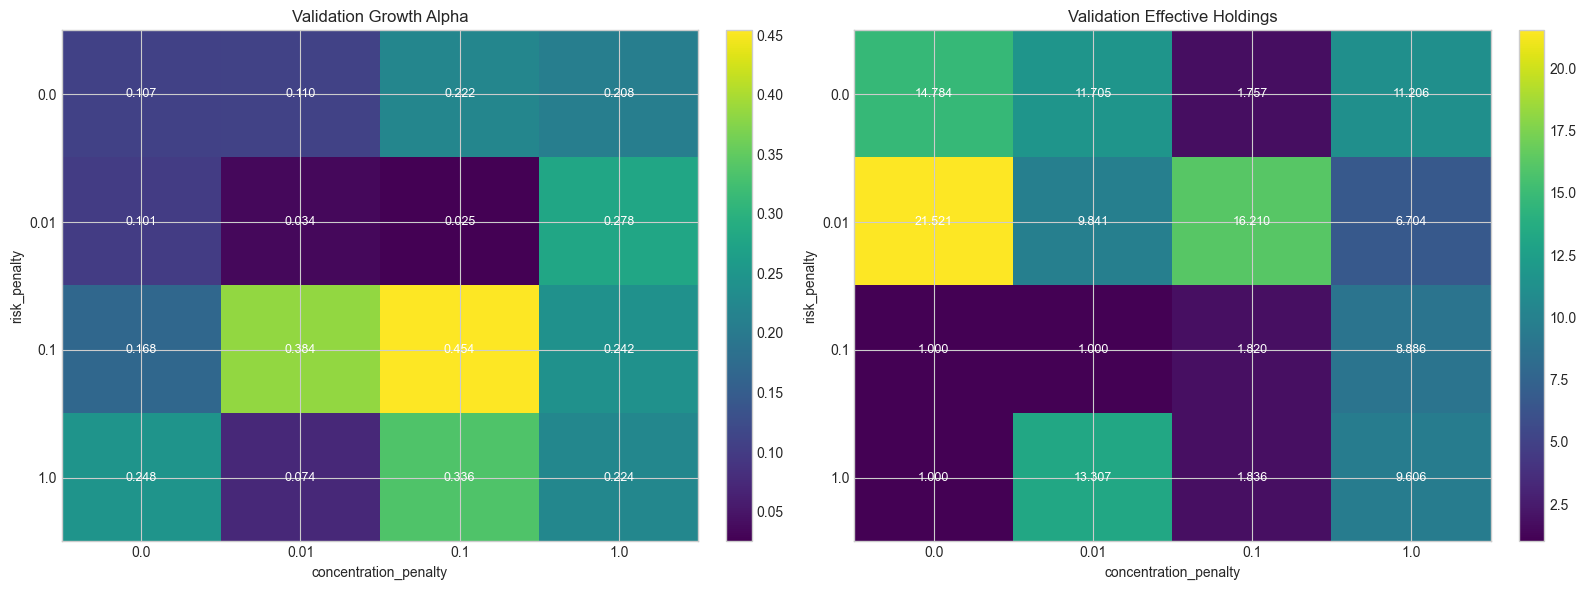

## VAL Run Summary

,evaluation_scope,run_id,risk_penalty,concentration_penalty,best_epoch,final_epoch,saved_best_val_growth_alpha,saved_best_val_effective_holdings,saved_final_val_growth_alpha,saved_final_val_effective_holdings,strategy_label,sample_count,portfolio_growth_mean,benchmark_growth_mean,growth_alpha_mean,max_weight_mean,effective_holdings_mean,ticker_count_mean,cumulative_growth,benchmark_cumulative_growth,cumulative_alpha
0,val,10,0.10,0.10,381,1000,0.453976,1.820383,0.414873,1.651459,run 10 | risk=0.1 | conc=0.1,2,1.632326,1.178345,0.453981,0.728343,1.820342,58.0,2.637347,1.386374,1.250974
1,val,9,0.10,0.01,1000,1000,0.384493,1.000014,0.384493,1.000014,run 9 | risk=0.1 | conc=0.01,2,1.562838,1.178345,0.384493,0.999993,1.000014,58.0,2.429170,1.386374,1.042796
2,val,14,1.00,0.10,124,1000,0.336443,1.836731,0.348238,1.513719,run 14 | risk=1.0 | conc=0.1,2,1.514800,1.178345,0.336455,0.701748,1.836396,58.0,2.283402,1.386374,0.897029
3,val,7,0.01,1.00,826,1000,0.278360,6.705690,0.220185,6.750131,run 7 | risk=0.01 | conc=1.0,2,1.456746,1.178345,0.278401,0.219752,6.703662,58.0,2.103850,1.386374,0.717476
4,val,12,1.00,0.00,994,1000,0.247508,1.000047,0.247508,1.000046,run 12 | risk=1.0 | conc=0.0,2,1.425853,1.178345,0.247508,0.999977,1.000047,58.0,1.978008,1.386374,0.591634
5,val,11,0.10,1.00,226,1000,0.242060,8.887571,0.161510,9.338081,run 11 | risk=0.1 | conc=1.0,2,1.420409,1.178345,0.242064,0.169982,8.886433,58.0,2.014452,1.386374,0.628079
6,val,15,1.00,1.00,848,1000,0.223894,9.605568,0.216052,8.496717,run 15 | risk=1.0 | conc=1.0,2,1.402236,1.178345,0.223891,0.163527,9.605543,58.0,1.943776,1.386374,0.557403
7,val,2,0.00,0.10,557,1000,0.222207,1.757361,0.173105,2.049474,run 2 | risk=0.0 | conc=0.1,2,1.400561,1.178345,0.222216,0.697661,1.757194,58.0,1.911691,1.386374,0.525318
8,val,3,0.00,1.00,721,1000,0.208067,11.207038,0.187963,10.889301,run 3 | risk=0.0 | conc=1.0,2,1.386409,1.178345,0.208064,0.166495,11.206265,58.0,1.894592,1.386374,0.508218
9,val,8,0.10,0.00,560,1000,0.168414,1.000124,0.168414,1.000039,run 8 | risk=0.1 | conc=0.0,2,1.346759,1.178345,0.168414,0.999938,1.000124,58.0,1.809369,1.386374,0.422995


## VAL Top 5 Quarter-by-Quarter Growth

,evaluation_scope,source_split,run_id,sample_key,time_range,quarter_end_date,risk_penalty,concentration_penalty,ticker_count,portfolio_growth,benchmark_growth,growth_alpha,max_weight,effective_holdings,strategy_label
0,val,val,7,val__q4y2023__2023-12-31,q4y2023,2023-12-31,0.01,1.00,58,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
1,val,val,7,val__q1y2024__2024-03-31,q1y2024,2024-03-31,0.01,1.00,58,1.321617,1.132263,0.189354,0.212181,6.067985,run 7 | risk=0.01 | conc=1.0
2,val,val,9,val__q4y2023__2023-12-31,q4y2023,2023-12-31,0.10,0.01,58,1.447540,1.224428,0.223112,0.999994,1.000012,run 9 | risk=0.1 | conc=0.01
3,val,val,9,val__q1y2024__2024-03-31,q1y2024,2024-03-31,0.10,0.01,58,1.678137,1.132263,0.545874,0.999992,1.000017,run 9 | risk=0.1 | conc=0.01
4,val,val,10,val__q4y2023__2023-12-31,q4y2023,2023-12-31,0.10,0.10,58,1.797075,1.224428,0.572647,0.882831,1.269813,run 10 | risk=0.1 | conc=0.1
5,val,val,10,val__q1y2024__2024-03-31,q1y2024,2024-03-31,0.10,0.10,58,1.467578,1.132263,0.335316,0.573854,2.370871,run 10 | risk=0.1 | conc=0.1
6,val,val,12,val__q4y2023__2023-12-31,q4y2023,2023-12-31,1.00,0.00,58,1.660476,1.224428,0.436048,0.999986,1.000029,run 12 | risk=1.0 | conc=0.0
7,val,val,12,val__q1y2024__2024-03-31,q1y2024,2024-03-31,1.00,0.00,58,1.191229,1.132263,0.058967,0.999968,1.000065,run 12 | risk=1.0 | conc=0.0
8,val,val,14,val__q4y2023__2023-12-31,q4y2023,2023-12-31,1.00,0.10,58,1.620704,1.224428,0.396277,0.722046,1.755133,run 14 | risk=1.0 | conc=0.1
9,val,val,14,val__q1y2024__2024-03-31,q1y2024,2024-03-31,1.00,0.10,58,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1


## VAL Top 5 Allocation Weights by Ticker

,evaluation_scope,source_split,run_id,risk_penalty,concentration_penalty,sample_key,time_range,quarter_end_date,ticker,weight,equal_weight,current_price,future_price,ticker_return,portfolio_growth,benchmark_growth,growth_alpha,max_weight,effective_holdings,strategy_label
0,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,META,0.227322,0.017241,351.230011,583.210022,0.660479,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
1,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,NFLX,0.172149,0.017241,48.689999,89.129997,0.830561,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
2,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,KMI,0.139537,0.017241,15.810000,25.990000,0.643896,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
3,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,F,0.128999,0.017241,10.510000,9.130000,-0.131304,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
4,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,RTX,0.089807,0.017241,80.419998,113.209999,0.407734,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,TMO,0.000002,0.017241,577.380005,495.750000,-0.141380,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1
576,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,V,0.000002,0.017241,274.959991,347.869995,0.265166,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1
577,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,MCD,0.000002,0.017241,269.000000,305.290009,0.134907,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1
578,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,LIN,0.000002,0.017241,452.489990,459.480011,0.015448,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1


## VAL Top Holdings Price Table

,evaluation_scope,source_split,run_id,risk_penalty,concentration_penalty,sample_key,time_range,quarter_end_date,ticker,weight,equal_weight,current_price,future_price,ticker_return,portfolio_growth,benchmark_growth,growth_alpha,max_weight,effective_holdings,strategy_label
0,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,META,0.227322,0.017241,351.230011,583.210022,0.660479,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
1,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,NFLX,0.172149,0.017241,48.689999,89.129997,0.830561,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
2,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,KMI,0.139537,0.017241,15.810000,25.990000,0.643896,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
3,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,F,0.128999,0.017241,10.510000,9.130000,-0.131304,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
4,val,val,7,0.01,1.0,val__q4y2023__2023-12-31,q4y2023,2023-12-31,RTX,0.089807,0.017241,80.419998,113.209999,0.407734,1.591876,1.224428,0.367448,0.227322,7.339339,run 7 | risk=0.01 | conc=1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,XOM,0.000056,0.017241,108.690002,114.980003,0.057871,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1
96,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,GD,0.000031,0.017241,271.670013,267.440002,-0.015570,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1
97,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,CVS,0.000031,0.017241,73.510002,65.279999,-0.111958,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1
98,val,val,14,1.00,0.1,val__q1y2024__2024-03-31,q1y2024,2024-03-31,NFLX,0.000023,0.017241,60.730000,93.250000,0.535485,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1


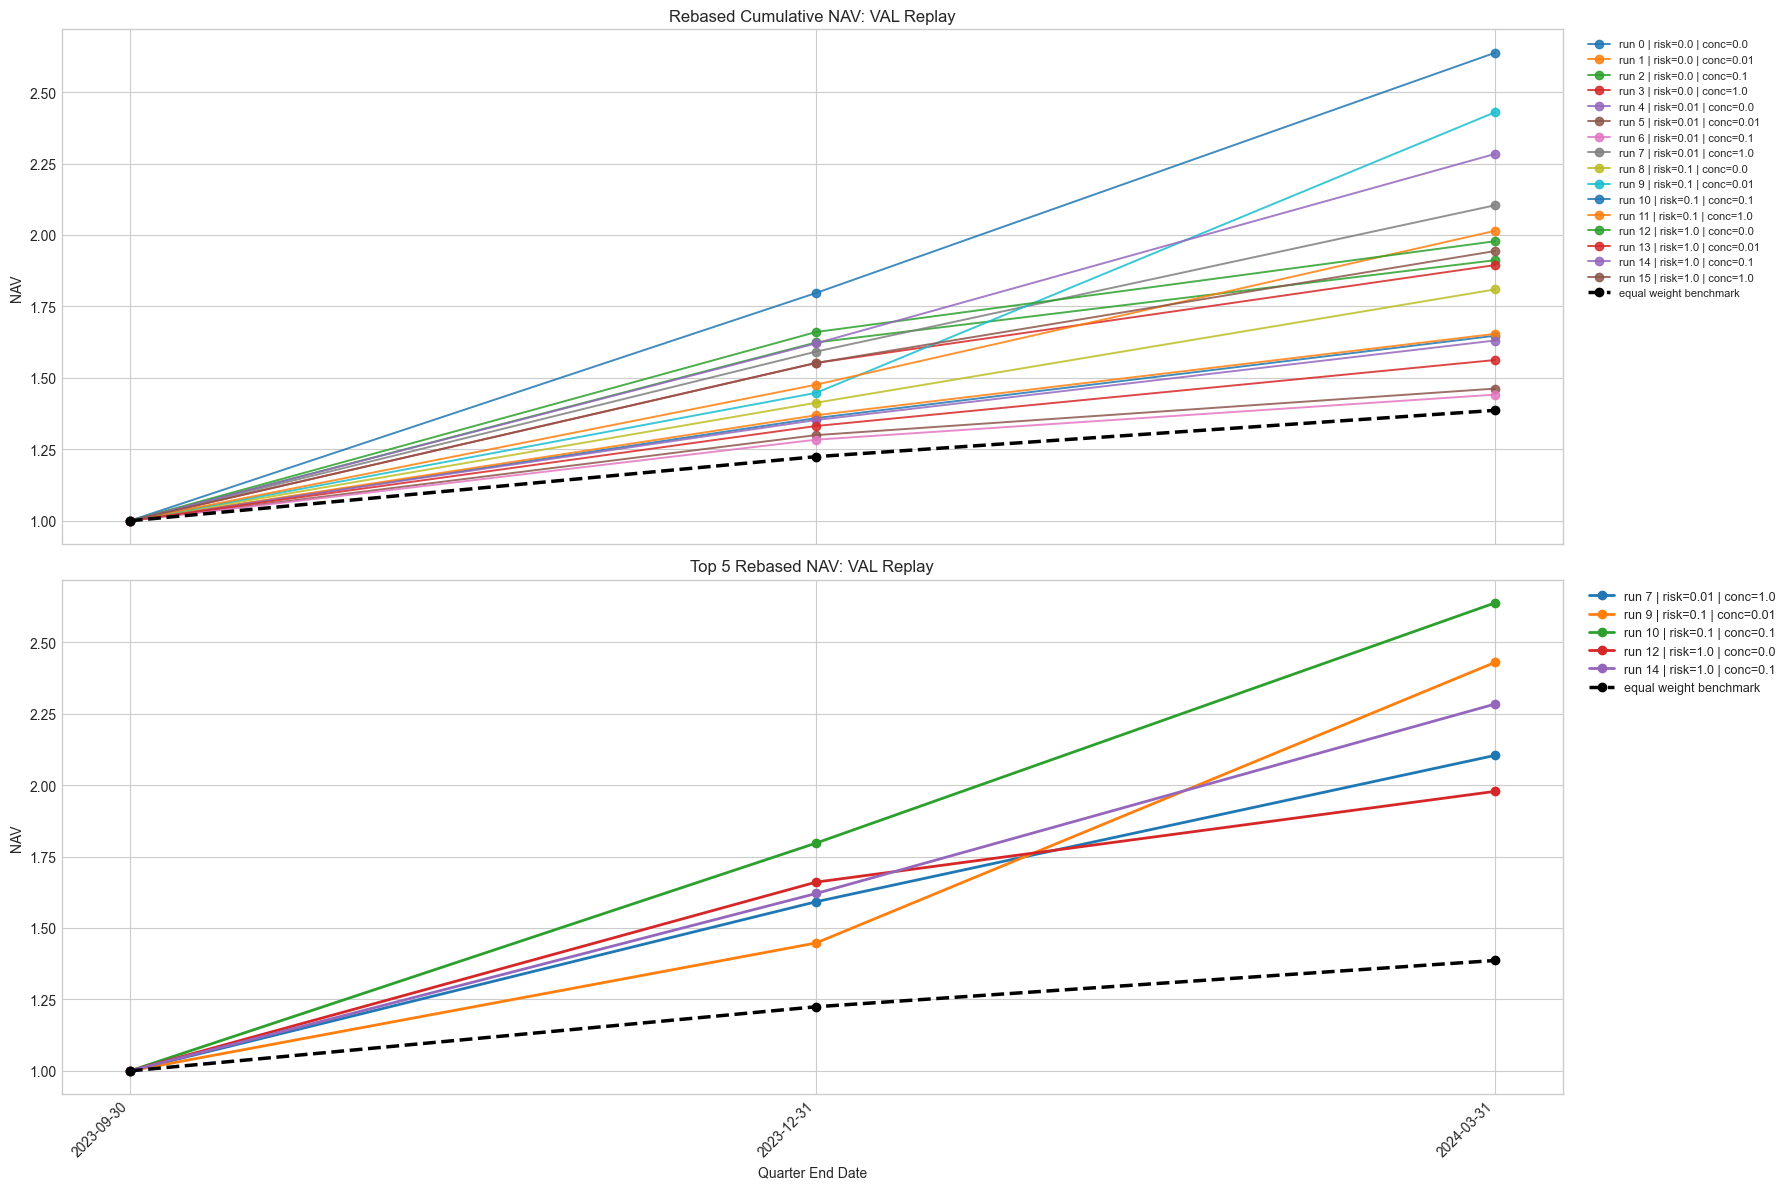

## ALL Run Summary

,evaluation_scope,run_id,risk_penalty,concentration_penalty,best_epoch,final_epoch,saved_best_val_growth_alpha,saved_best_val_effective_holdings,saved_final_val_growth_alpha,saved_final_val_effective_holdings,strategy_label,sample_count,portfolio_growth_mean,benchmark_growth_mean,growth_alpha_mean,max_weight_mean,effective_holdings_mean,ticker_count_mean,cumulative_growth,benchmark_cumulative_growth,cumulative_alpha
0,all,12,1.00,0.00,994,1000,0.247508,1.000047,0.247508,1.000046,run 12 | risk=1.0 | conc=0.0,14,1.759092,1.117676,0.641416,0.999987,1.000025,57.0,1712.204395,3.981414,1708.222981
1,all,2,0.00,0.10,557,1000,0.222207,1.757361,0.173105,2.049474,run 2 | risk=0.0 | conc=0.1,14,1.747590,1.117676,0.629914,0.770869,1.603900,57.0,1550.039497,3.981414,1546.058083
2,all,10,0.10,0.10,381,1000,0.453976,1.820383,0.414873,1.651459,run 10 | risk=0.1 | conc=0.1,14,1.727728,1.117676,0.610052,0.645680,2.099137,57.0,1538.971661,3.981414,1534.990246
3,all,7,0.01,1.00,826,1000,0.278360,6.705690,0.220185,6.750131,run 7 | risk=0.01 | conc=1.0,14,1.672040,1.117676,0.554364,0.252602,6.952275,57.0,861.447242,3.981414,857.465827
4,all,3,0.00,1.00,721,1000,0.208067,11.207038,0.187963,10.889301,run 3 | risk=0.0 | conc=1.0,14,1.640980,1.117676,0.523305,0.228324,7.929687,57.0,691.805656,3.981414,687.824241
5,all,14,1.00,0.10,124,1000,0.336443,1.836731,0.348238,1.513719,run 14 | risk=1.0 | conc=0.1,14,1.635181,1.117676,0.517505,0.693818,1.873466,57.0,825.809193,3.981414,821.827779
6,all,15,1.00,1.00,848,1000,0.223894,9.605568,0.216052,8.496717,run 15 | risk=1.0 | conc=1.0,14,1.615316,1.117676,0.497640,0.200228,8.871911,57.0,553.225025,3.981414,549.243610
7,all,9,0.10,0.01,1000,1000,0.384493,1.000014,0.384493,1.000014,run 9 | risk=0.1 | conc=0.01,14,1.576467,1.117676,0.458791,0.999993,1.000013,57.0,533.130820,3.981414,529.149406
8,all,11,0.10,1.00,226,1000,0.242060,8.887571,0.161510,9.338081,run 11 | risk=0.1 | conc=1.0,14,1.541196,1.117676,0.423520,0.205282,8.858717,57.0,355.117673,3.981414,351.136259
9,all,8,0.10,0.00,560,1000,0.168414,1.000124,0.168414,1.000039,run 8 | risk=0.1 | conc=0.0,14,1.455515,1.117676,0.337839,0.999970,1.000060,57.0,172.342863,3.981414,168.361449


## ALL Top 5 Quarter-by-Quarter Growth

,evaluation_scope,source_split,run_id,sample_key,time_range,quarter_end_date,risk_penalty,concentration_penalty,ticker_count,portfolio_growth,benchmark_growth,growth_alpha,max_weight,effective_holdings,strategy_label
0,all,train,7,train__q1y2021__2021-03-31,q1y2021,2021-03-31,0.01,1.0,55,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
1,all,train,7,train__q2y2021__2021-06-30,q2y2021,2021-06-30,0.01,1.0,57,1.339347,0.882806,0.456542,0.174553,9.436936,run 7 | risk=0.01 | conc=1.0
2,all,train,7,train__q3y2021__2021-09-30,q3y2021,2021-09-30,0.01,1.0,57,1.322532,0.815264,0.507267,0.191634,9.133887,run 7 | risk=0.01 | conc=1.0
3,all,train,7,train__q4y2021__2021-12-31,q4y2021,2021-12-31,0.01,1.0,57,1.386374,0.856337,0.530037,0.264171,7.183139,run 7 | risk=0.01 | conc=1.0
4,all,train,7,train__q1y2022__2022-03-31,q1y2022,2022-03-31,0.01,1.0,57,1.280699,0.976220,0.304479,0.204746,7.208005,run 7 | risk=0.01 | conc=1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,all,train,14,train__q2y2023__2023-06-30,q2y2023,2023-06-30,1.00,0.1,57,1.779711,1.249661,0.530050,0.768540,1.554736,run 14 | risk=1.0 | conc=0.1
66,all,train,14,train__q3y2023__2023-09-30,q3y2023,2023-09-30,1.00,0.1,57,2.093488,1.339411,0.754077,0.733698,1.668196,run 14 | risk=1.0 | conc=0.1
67,all,val,14,val__q4y2023__2023-12-31,q4y2023,2023-12-31,1.00,0.1,58,1.620704,1.224428,0.396277,0.722046,1.755133,run 14 | risk=1.0 | conc=0.1
68,all,val,14,val__q1y2024__2024-03-31,q1y2024,2024-03-31,1.00,0.1,58,1.408895,1.132263,0.276633,0.681449,1.917659,run 14 | risk=1.0 | conc=0.1


## ALL Top 5 Allocation Weights by Ticker

,evaluation_scope,source_split,run_id,risk_penalty,concentration_penalty,sample_key,time_range,quarter_end_date,ticker,weight,equal_weight,current_price,future_price,ticker_return,portfolio_growth,benchmark_growth,growth_alpha,max_weight,effective_holdings,strategy_label
0,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,LLY,0.172952,0.018182,177.779999,276.640015,0.556081,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
1,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,ABBV,0.156206,0.018182,89.290001,139.990005,0.567813,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
2,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,XOM,0.140081,0.018182,46.080002,71.959999,0.561632,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
3,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,PFE,0.134787,0.018182,28.200001,41.750000,0.480496,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
4,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,F,0.109273,0.018182,9.680000,13.500000,0.394628,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3985,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,V,0.000003,0.017544,259.079987,322.209991,0.243670,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1
3986,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,TMO,0.000003,0.017544,549.729980,425.850006,-0.225347,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1
3987,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,MCD,0.000002,0.017544,244.699997,299.829987,0.225296,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1
3988,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,LIN,0.000002,0.017544,429.010010,426.170013,-0.006620,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1


## ALL Top Holdings Price Table

,evaluation_scope,source_split,run_id,risk_penalty,concentration_penalty,sample_key,time_range,quarter_end_date,ticker,weight,equal_weight,current_price,future_price,ticker_return,portfolio_growth,benchmark_growth,growth_alpha,max_weight,effective_holdings,strategy_label
0,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,LLY,0.172952,0.018182,177.779999,276.640015,0.556081,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
1,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,ABBV,0.156206,0.018182,89.290001,139.990005,0.567813,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
2,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,XOM,0.140081,0.018182,46.080002,71.959999,0.561632,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
3,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,PFE,0.134787,0.018182,28.200001,41.750000,0.480496,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
4,all,train,7,0.01,1.0,train__q1y2021__2021-03-31,q1y2021,2021-03-31,F,0.109273,0.018182,9.680000,13.500000,0.394628,1.486049,1.096818,0.389232,0.172952,8.045219,run 7 | risk=0.01 | conc=1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,GD,0.000066,0.017544,280.410004,266.690002,-0.048928,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1
696,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,XOM,0.000044,0.017544,108.510002,96.610001,-0.109667,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1
697,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,CVS,0.000043,0.017544,54.950001,66.459999,0.209463,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1
698,all,test,14,1.00,0.1,test__q2y2024__2024-06-30,q2y2024,2024-06-30,BMY,0.000034,0.017544,37.689999,48.049999,0.274874,1.130134,1.034122,0.096012,0.629530,2.115671,run 14 | risk=1.0 | conc=0.1


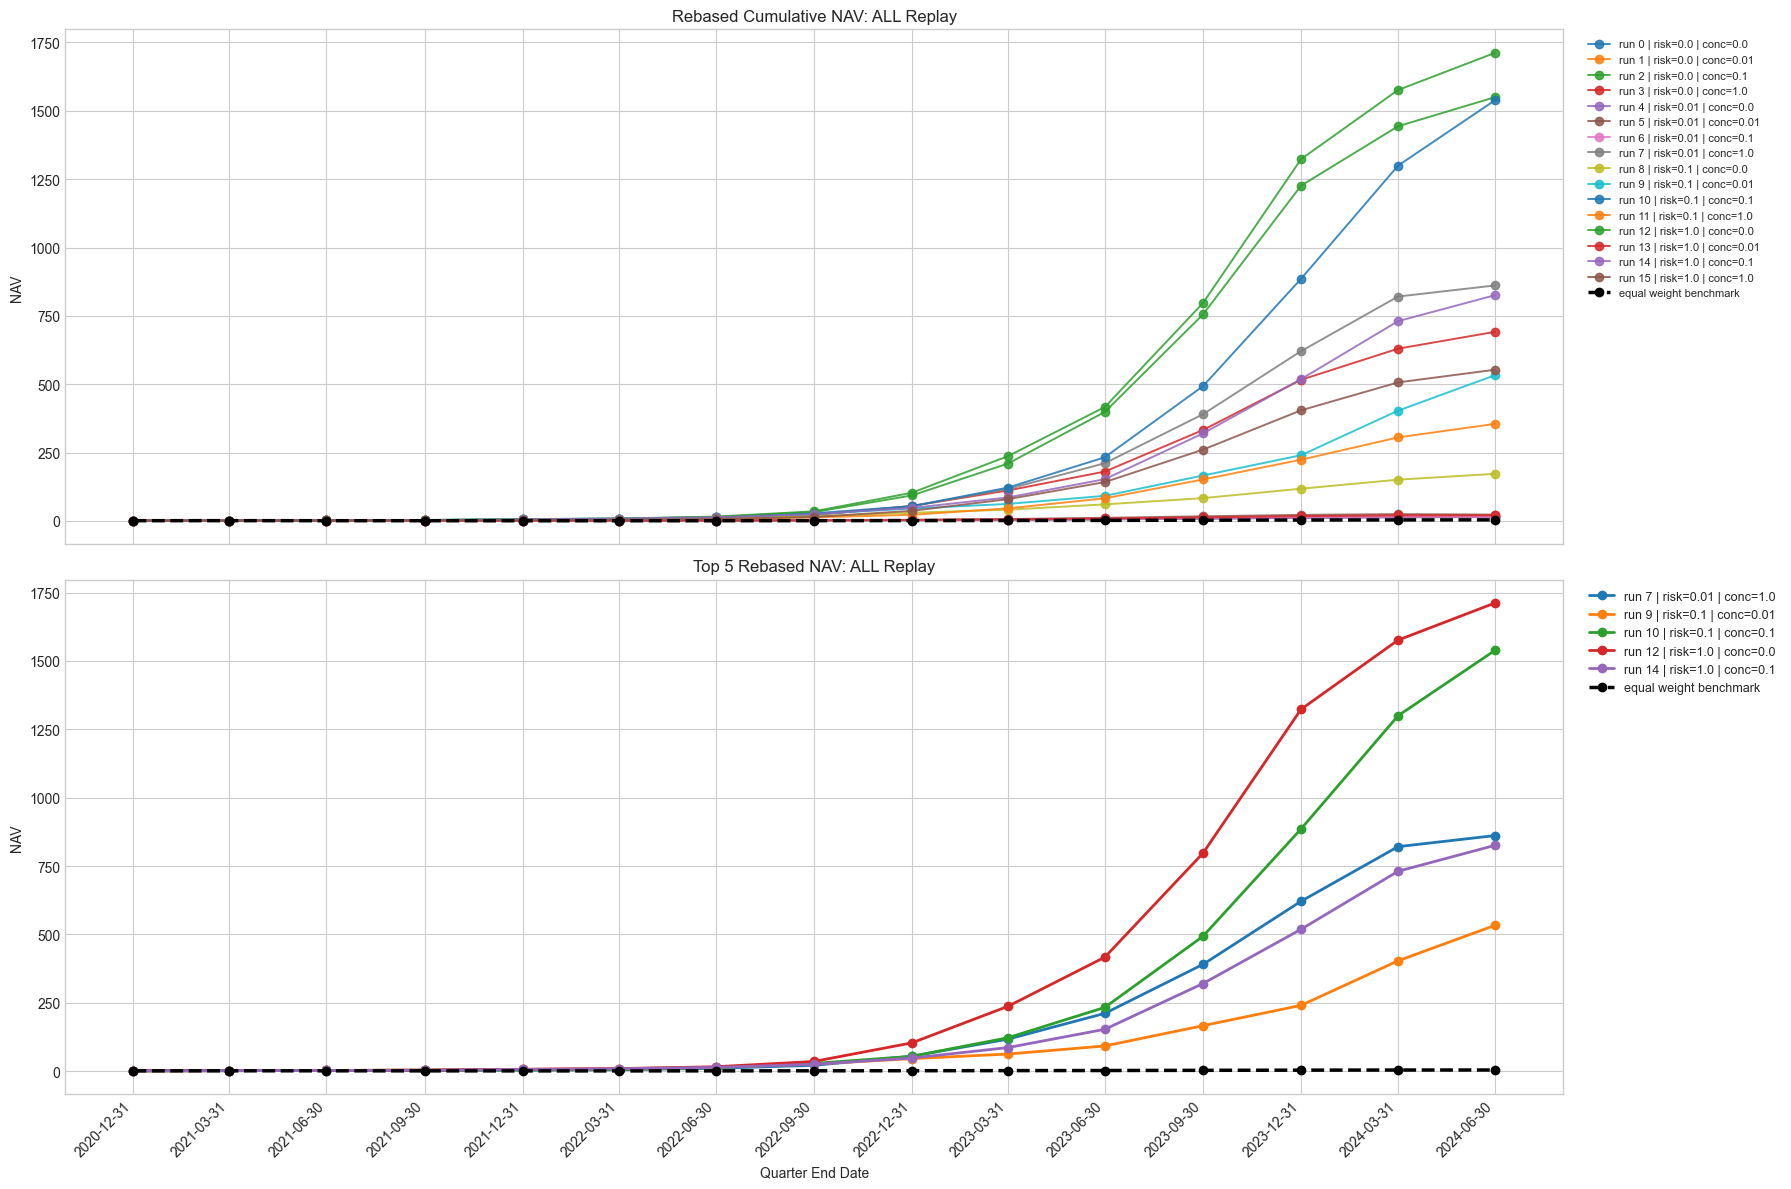

## Saved Outputs

,scope,run_summary,sample_weights,growth_by_quarter,top5_allocations,top_holdings_prices,growth_plot,diagnostics_csv,summary_json,heatmap_plot
0,val,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,NaN,NaN,NaN
1,all,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,NaN,NaN,NaN
2,shared,NaN,NaN,NaN,NaN,NaN,NaN,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...,/Users/tanny/Documents/Projects/Big-Data-AI-Pr...


In [12]:
scope_results = {scope: summarize_scope(run_dirs, scope, device) for scope in EVALUATION_SCOPES}
val_run_summary_df = scope_results["val"]["run_summary"]
top_runs = val_run_summary_df.head(TOP_STRATEGY_COUNT)["run_id"].tolist()

summary_json_path = multirun_root / "portfolio_eval_summary.json"
heatmap_plot_path = multirun_root / "portfolio_eval_heatmaps_val.png"
diagnostics_csv_path = multirun_root / "portfolio_eval_val_diagnostics.csv"

display(Markdown("## Validation Run Ranking"))
display(val_run_summary_df)
display(Markdown(f"## Top {TOP_STRATEGY_COUNT} Strategies Selected from Validation Ranking"))
display(val_run_summary_df.head(TOP_STRATEGY_COUNT))

alpha_heatmap = (
    val_run_summary_df.pivot(index="risk_penalty", columns="concentration_penalty", values="growth_alpha_mean")
    .sort_index()
    .sort_index(axis=1)
)
holdings_heatmap = (
    val_run_summary_df.pivot(index="risk_penalty", columns="concentration_penalty", values="effective_holdings_mean")
    .sort_index()
    .sort_index(axis=1)
)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, matrix, title in [
    (axes[0], alpha_heatmap, "Validation Growth Alpha"),
    (axes[1], holdings_heatmap, "Validation Effective Holdings"),
]:
    image = ax.imshow(matrix.values, aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("concentration_penalty")
    ax.set_ylabel("risk_penalty")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels([str(column) for column in matrix.columns])
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels([str(index) for index in matrix.index])
    for row_idx in range(matrix.shape[0]):
        for col_idx in range(matrix.shape[1]):
            ax.text(col_idx, row_idx, f"{matrix.iloc[row_idx, col_idx]:.3f}", ha="center", va="center", color="white", fontsize=9)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
if WRITE_OUTPUTS:
    fig.savefig(heatmap_plot_path, dpi=150, bbox_inches="tight")
plt.show()

output_rows = []
summary_payload = {
    "multirun_root": str(multirun_root),
    "top_runs_from_val": top_runs,
    "scopes": {},
}

for scope, result in scope_results.items():
    run_summary_df = result["run_summary"]
    weights_df = result["weights"]
    sample_summary_df = result["sample_summary"]
    scope_output_paths = make_output_paths(multirun_root, scope)

    benchmark_curve_df = (
        sample_summary_df.groupby(["evaluation_scope", "source_split", "quarter_end_date", "time_range"], as_index=False)["benchmark_growth"]
        .mean()
        .sort_values(["quarter_end_date", "source_split"])
    )
    base_date = pd.Timestamp(benchmark_curve_df["quarter_end_date"].min()) - pd.offsets.QuarterEnd(1)
    benchmark_curve_df["strategy_label"] = "equal weight benchmark"
    benchmark_nav_df = build_rebased_curve(
        benchmark_curve_df,
        value_column="benchmark_growth",
        group_columns=["strategy_label"],
        label_column="strategy_label",
        base_date=base_date,
    )

    strategy_curve_df = (
        sample_summary_df.groupby(["run_id", "risk_penalty", "concentration_penalty", "source_split", "quarter_end_date", "time_range"], as_index=False)["portfolio_growth"]
        .mean()
        .sort_values(["run_id", "quarter_end_date", "source_split"])
    )
    strategy_curve_df["strategy_label"] = strategy_curve_df.apply(
        lambda row: f"run {int(row['run_id'])} | risk={row['risk_penalty']} | conc={row['concentration_penalty']}",
        axis=1,
    )
    strategy_nav_df = build_rebased_curve(
        strategy_curve_df,
        value_column="portfolio_growth",
        group_columns=["run_id", "risk_penalty", "concentration_penalty"],
        label_column="strategy_label",
        base_date=base_date,
    )

    top5_growth_df = sample_summary_df.loc[sample_summary_df["run_id"].isin(top_runs)].copy()
    top5_growth_df = top5_growth_df.merge(
        val_run_summary_df[["run_id", "strategy_label"]],
        on="run_id",
        how="left",
    ).sort_values(["run_id", "quarter_end_date", "source_split"]).reset_index(drop=True)
    top5_allocations_df = weights_df.loc[weights_df["run_id"].isin(top_runs)].copy()
    top5_allocations_df = top5_allocations_df.merge(
        val_run_summary_df[["run_id", "strategy_label"]],
        on="run_id",
        how="left",
    ).sort_values(["run_id", "quarter_end_date", "source_split", "weight", "ticker"], ascending=[True, True, True, False, True]).reset_index(drop=True)
    top5_top_holdings_df = (
        top5_allocations_df.groupby(["run_id", "quarter_end_date", "source_split"], group_keys=False)
        .head(TOP_HOLDINGS_PER_QUARTER)
        .reset_index(drop=True)
    )

    display(Markdown(f"## {scope.upper()} Run Summary"))
    display(run_summary_df)
    display(Markdown(f"## {scope.upper()} Top {TOP_STRATEGY_COUNT} Quarter-by-Quarter Growth"))
    display(top5_growth_df)
    display(Markdown(f"## {scope.upper()} Top {TOP_STRATEGY_COUNT} Allocation Weights by Ticker"))
    display(top5_allocations_df)
    display(Markdown(f"## {scope.upper()} Top Holdings Price Table"))
    display(top5_top_holdings_df)

    fig, axes = plt.subplots(2, 1, figsize=(18, 12), sharex=True)
    actual_dates = sorted(pd.to_datetime(sample_summary_df["quarter_end_date"].dropna().unique()).tolist())
    tick_dates = [base_date] + actual_dates
    tick_positions, tick_labels = quarter_tick_labels(tick_dates)

    for run_id, group in strategy_nav_df.groupby("run_id"):
        label = group["strategy_label"].iloc[0]
        axes[0].plot(group["quarter_end_date"], group["rebased_nav"], marker="o", linewidth=1.4, alpha=0.85, label=label)
    axes[0].plot(
        benchmark_nav_df["quarter_end_date"],
        benchmark_nav_df["rebased_nav"],
        color="black",
        linewidth=2.5,
        linestyle="--",
        marker="o",
        label="equal weight benchmark",
    )
    axes[0].set_title(f"Rebased Cumulative NAV: {scope.upper()} Replay")
    axes[0].set_ylabel("NAV")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

    top5_nav_df = strategy_nav_df.loc[strategy_nav_df["run_id"].isin(top_runs)].copy()
    for run_id, group in top5_nav_df.groupby("run_id"):
        label = group["strategy_label"].iloc[0]
        axes[1].plot(group["quarter_end_date"], group["rebased_nav"], marker="o", linewidth=2, label=label)
    axes[1].plot(
        benchmark_nav_df["quarter_end_date"],
        benchmark_nav_df["rebased_nav"],
        color="black",
        linewidth=2.5,
        linestyle="--",
        marker="o",
        label="equal weight benchmark",
    )
    axes[1].set_title(f"Top {TOP_STRATEGY_COUNT} Rebased NAV: {scope.upper()} Replay")
    axes[1].set_ylabel("NAV")
    axes[1].set_xlabel("Quarter End Date")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

    for ax in axes:
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    plt.tight_layout()
    if WRITE_OUTPUTS:
        fig.savefig(scope_output_paths["growth_plot"], dpi=150, bbox_inches="tight")
    plt.show()

    summary_payload["scopes"][scope] = {
        "run_count": int(len(run_summary_df)),
        "sample_count": int(len(sample_summary_df)),
        "dates": sorted({pd.Timestamp(date).strftime("%Y-%m-%d") for date in sample_summary_df["quarter_end_date"].dropna()}),
        "top_strategies": run_summary_df.head(TOP_STRATEGY_COUNT).to_dict(orient="records"),
        "benchmark_terminal_nav": float(benchmark_nav_df["rebased_nav"].iloc[-1]),
    }

    if WRITE_OUTPUTS:
        run_summary_df.to_csv(scope_output_paths["run_summary"], index=False)
        weights_df.to_csv(scope_output_paths["sample_weights"], index=False)
        top5_growth_df.to_csv(scope_output_paths["growth_by_quarter"], index=False)
        top5_allocations_df.to_csv(scope_output_paths["top5_allocations"], index=False)
        top5_top_holdings_df.to_csv(scope_output_paths["top_holdings_prices"], index=False)

    output_rows.append({
        "scope": scope,
        **{key: str(value) for key, value in scope_output_paths.items()},
    })

if WRITE_OUTPUTS:
    diagnostics_export_df = target_counts_df.copy()
    diagnostics_export_df.to_csv(diagnostics_csv_path, index=False)
    summary_json_path.write_text(json.dumps(summary_payload, indent=2, default=str))

output_rows.append({
    "scope": "shared",
    "diagnostics_csv": str(diagnostics_csv_path),
    "summary_json": str(summary_json_path),
    "heatmap_plot": str(heatmap_plot_path),
})

display(Markdown("## Saved Outputs"))
display(pd.DataFrame(output_rows))
